# Introduction

This project builds a Probability of Default (PD) model using borrower financial data to estimate the likelihood of loan default and compute the expected financial loss for the lender.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [2]:
df = pd.read_csv("Loan_data.csv")

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

In [5]:
df.isnull().sum().sum()

np.int64(0)

There are no missing values in the dataset.

In [15]:
df.default.value_counts()

default
0    8149
1    1851
Name: count, dtype: int64

There is a class imbalance in the data. Stratification of the target is needed while training.

In [6]:
y = df['default']
X = df.drop(columns = ['default', 'customer_id'])

#### Training Logistic Regression model

In [7]:
# Split the data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform test
X_test_scaled = scaler.transform(X_test)

# Train the model 
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict on test
probabilities = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

#### Evaluating the classification performance of the model by analyzing the confusion matrix

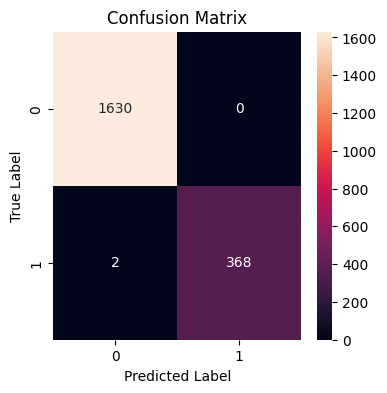

In [8]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (4,4))
sns.heatmap(matrix, annot = True, fmt ='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows near-perfect classification performance, with zero false positives and only two false negatives, indicating extremely high accuracy in identifying both default and non-default borrowers.

#### Computing the ROC AUC score to measure the model’s ability to rank defaulters above non-defaulters

In [9]:
auc = roc_auc_score(y_test, probabilities)

print("ROC AUC:", auc)
print(classification_report(y_test, y_pred))

ROC AUC: 0.9999883933012768
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1630
           1       1.00      0.99      1.00       370

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



The ROC AUC score is approximately 0.9999, indicating almost perfect discrimination between default and non-default borrowers.

#### Examining the Logistic Regression coefficients 

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})
importance

,Feature,Coefficient
0,credit_lines_outstanding,8.747702
1,loan_amt_outstanding,0.118859
2,total_debt_outstanding,3.837128
3,income,-2.354434
4,years_employed,-2.903099
5,fico_score,-1.135559


#### Expected Loss Calculation

The expected financial loss of a loan is calculated using:

$$
\text{Expected Loss (EL)} = PD \times EAD \times LGD
$$

Where:

* $PD$ = Probability of Default (predicted by the model)
* $EAD$ = Exposure at Default (loan amount outstanding)
* $LGD$ = Loss Given Default

##### Assumption

We assume a recovery rate of 10%, therefore:

$$
LGD = 1 - 0.10 = 0.90
$$


In [ ]:
def expected_loss(features, model, scaler, recovery_rate=0.10):
    
    # Scale the input features using the previously fitted scaler
    features_scaled = scaler.transform([features])    
    
    # Predict Probability of Default (PD)
    prob_default = model.predict_proba(features_scaled)[:, 1][0]
    
    # Exposure at Default (EAD)
    loan_amount = features[1]
    
    # Loss Given Default (LGD)
    # LGD = 1 - Recovery Rate
    lgd = 1 - recovery_rate
    
    # Expected Loss formula:
    # EL = PD × EAD × LGD
    return prob_default * loan_amount * lgd

In [12]:
features = [5,1958,8228,26648,2,572]
expected_loss(features, model, scaler)

c:\Users\samid\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(1762.1995368247565)

Summary

This project develops a credit risk model to predict the Probability of Default (PD) using borrower financial data. Logistic Regression achieved near-perfect performance, with a ROC AUC of approximately 0.9999, indicating almost perfect discrimination between default and non-default borrowers.

The confusion matrix and classification report further confirm the model’s strong performance, showing extremely high precision and recall for both classes, with only a small number of misclassifications. These results demonstrate that the model accurately identifies defaulters while maintaining strong overall classification accuracy.